In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dataguruji/ipl-data/598025.json
/kaggle/input/datasets/dataguruji/ipl-data/1473452.json
/kaggle/input/datasets/dataguruji/ipl-data/598004.json
/kaggle/input/datasets/dataguruji/ipl-data/1370352.json
/kaggle/input/datasets/dataguruji/ipl-data/1216499.json
/kaggle/input/datasets/dataguruji/ipl-data/1082608.json
/kaggle/input/datasets/dataguruji/ipl-data/1082612.json
/kaggle/input/datasets/dataguruji/ipl-data/1254058.json
/kaggle/input/datasets/dataguruji/ipl-data/729303.json
/kaggle/input/datasets/dataguruji/ipl-data/419139.json
/kaggle/input/datasets/dataguruji/ipl-data/336020.json
/kaggle/input/datasets/dataguruji/ipl-data/1082620.json
/kaggle/input/datasets/dataguruji/ipl-data/980945.json
/kaggle/input/datasets/dataguruji/ipl-data/1473469.json
/kaggle/input/datasets/dataguruji/ipl-data/729287.json
/kaggle/input/datasets/dataguruji/ipl-data/419125.json
/kaggle/input/datasets/dataguruji/ipl-data/829761.json
/kaggle/input/datasets/dataguruji/ipl-data/548372.json
/k

In [2]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt

In [3]:
os.listdir('/kaggle/input')

['datasets']

In [4]:
json_folder = '/kaggle/input/datasets'

In [5]:
os.listdir('/kaggle/input/datasets')

['dataguruji']

In [6]:
json_folder = 'kaggle/input/datasets/dataguruji/ipl-data'

In [7]:
os.listdir('/kaggle/input/datasets/dataguruji/ipl-data')

['598025.json',
 '1473452.json',
 '598004.json',
 '1370352.json',
 '1216499.json',
 '1082608.json',
 '1082612.json',
 '1254058.json',
 '729303.json',
 '419139.json',
 '336020.json',
 '1082620.json',
 '980945.json',
 '1473469.json',
 '729287.json',
 '419125.json',
 '829761.json',
 '548372.json',
 '1136564.json',
 '419113.json',
 '1237178.json',
 '1254077.json',
 '392225.json',
 '734039.json',
 '729317.json',
 '1178420.json',
 '548343.json',
 '1304098.json',
 '1136604.json',
 '392237.json',
 '1082636.json',
 '1178404.json',
 '1216537.json',
 '1359523.json',
 '598008.json',
 '392185.json',
 '980925.json',
 '1473478.json',
 '501241.json',
 '1082615.json',
 '733983.json',
 '1254103.json',
 '1254085.json',
 '1426305.json',
 '501255.json',
 '1082631.json',
 '1359496.json',
 '1216510.json',
 '336017.json',
 '1359475.json',
 '829759.json',
 '1216501.json',
 '392231.json',
 '392181.json',
 '1359513.json',
 '1216494.json',
 '392212.json',
 '501218.json',
 '501203.json',
 '980949.json',
 '419150.j

In [8]:
json_folder = '/kaggle/input/datasets/dataguruji/ipl-data'

In [9]:
files = os.listdir(json_folder)

print(files[:5])
print("Total Files:", len(files))

['598025.json', '1473452.json', '598004.json', '1370352.json', '1216499.json']
Total Files: 1227


In [10]:
with open(f'{json_folder}/{files[0]}') as f:
    data = json.load(f)

print(data.keys())

dict_keys(['meta', 'info', 'innings'])


In [11]:
all_deliveries = []

In [12]:
for file in files:

    try:
        with open(f'{json_folder}/{file}') as f:
            match = json.load(f)

        # Match details
        match_id = file.replace('.json', '')

        # Season
        season = match['info']['season']

        # Winner
        winner = match['info'].get(
            'outcome', {}
        ).get('winner', 'No Result')

        # Toss winner
        toss_winner = match['info']['toss']['winner']

        # Toss decision
        toss_decision = match['info']['toss']['decision']

        # Innings loop
        for inning_number, inning in enumerate(
            match['innings'],
            start=1
        ):

            batting_team = inning['team']

            # Overs loop
            for over_data in inning['overs']:

                over = over_data['over']

                # Deliveries loop
                for delivery in over_data['deliveries']:

                    batter = delivery.get('batter')

                    bowler = delivery.get('bowler')

                    total_runs = delivery['runs']['total']

                    batsman_runs = delivery['runs']['batter']

                    # Wicket check
                    is_wicket = (
                        1 if 'wickets' in delivery else 0
                    )

                    row = {

                        'match_id': match_id,

                        'season': season,

                        'inning': inning_number,

                        'batting_team': batting_team,

                        'over': over,

                        'batter': batter,

                        'bowler': bowler,

                        'total_runs': total_runs,

                        'batsman_runs': batsman_runs,

                        'is_wicket': is_wicket,

                        'winner': winner,

                        'toss_winner': toss_winner,

                        'toss_decision': toss_decision
                    }

                    all_deliveries.append(row)

    except Exception as e:

        print(f"Error in {file}: {e}")

Error in README.txt: Expecting value: line 1 column 1 (char 0)


In [13]:
df = pd.DataFrame(all_deliveries)

In [14]:
df.head()

,match_id,season,inning,batting_team,over,batter,bowler,total_runs,batsman_runs,is_wicket,winner,toss_winner,toss_decision
0,598025,2013,1,Pune Warriors,0,RV Uthappa,P Kumar,2,2,0,Kings XI Punjab,Kings XI Punjab,field
1,598025,2013,1,Pune Warriors,0,RV Uthappa,P Kumar,1,1,0,Kings XI Punjab,Kings XI Punjab,field
2,598025,2013,1,Pune Warriors,0,AJ Finch,P Kumar,0,0,0,Kings XI Punjab,Kings XI Punjab,field
3,598025,2013,1,Pune Warriors,0,AJ Finch,P Kumar,1,1,0,Kings XI Punjab,Kings XI Punjab,field
4,598025,2013,1,Pune Warriors,0,RV Uthappa,P Kumar,1,0,0,Kings XI Punjab,Kings XI Punjab,field


In [15]:
print(df.shape)

(291574, 13)


In [16]:
df.to_csv('ipl_ball_by_ball.csv', index=False)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291574 entries, 0 to 291573
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   match_id       291574 non-null  object
 1   season         291574 non-null  object
 2   inning         291574 non-null  int64 
 3   batting_team   291574 non-null  object
 4   over           291574 non-null  int64 
 5   batter         291574 non-null  object
 6   bowler         291574 non-null  object
 7   total_runs     291574 non-null  int64 
 8   batsman_runs   291574 non-null  int64 
 9   is_wicket      291574 non-null  int64 
 10  winner         291574 non-null  object
 11  toss_winner    291574 non-null  object
 12  toss_decision  291574 non-null  object
dtypes: int64(5), object(8)
memory usage: 28.9+ MB


In [18]:
df.isnull().sum()

match_id         0
season           0
inning           0
batting_team     0
over             0
batter           0
bowler           0
total_runs       0
batsman_runs     0
is_wicket        0
winner           0
toss_winner      0
toss_decision    0
dtype: int64

In [19]:
print(df.duplicated().sum())

78026


In [20]:
print(df['winner'].unique())

['Kings XI Punjab' 'Kolkata Knight Riders' 'No Result' 'Gujarat Titans'
 'Mumbai Indians' 'Royal Challengers Bangalore' 'Chennai Super Kings'
 'Delhi Daredevils' 'Gujarat Lions' 'Sunrisers Hyderabad'
 'Rajasthan Royals' 'Deccan Chargers' 'Rising Pune Supergiant'
 'Lucknow Super Giants' 'Delhi Capitals' 'Royal Challengers Bengaluru'
 'Punjab Kings' 'Pune Warriors' 'Kochi Tuskers Kerala'
 'Rising Pune Supergiants']


In [21]:
team_replacements = {
    'Delhi Daredevils':'Delhi Capitals',
    'Kings XI Punjab':'Punjab Kings',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
    'Rising Pune Supergiant' : 'Rising Pune Supergiants'
}


In [22]:
df['winner'] = df['winner'].replace(team_replacements)

df['toss_winner'] = df['toss_winner'].replace(team_replacements)

df['batting_team'] = df['batting_team'].replace(team_replacements)

In [23]:
print(df.dtypes)

match_id         object
season           object
inning            int64
batting_team     object
over              int64
batter           object
bowler           object
total_runs        int64
batsman_runs      int64
is_wicket         int64
winner           object
toss_winner      object
toss_decision    object
dtype: object



# Toss ANALYSIS

In [24]:
matches = df[['match_id', 'toss_winner', 'winner']].drop_duplicates()

In [25]:
matches.head()

print(matches.shape)

(1226, 3)


In [26]:
matches['toss_match_win'] = matches['toss_winner'] == matches['winner']

In [27]:
toss_result = matches['toss_match_win'].value_counts(normalize=True) * 100

print(toss_result)

toss_match_win
True     50.570962
False    49.429038
Name: proportion, dtype: float64


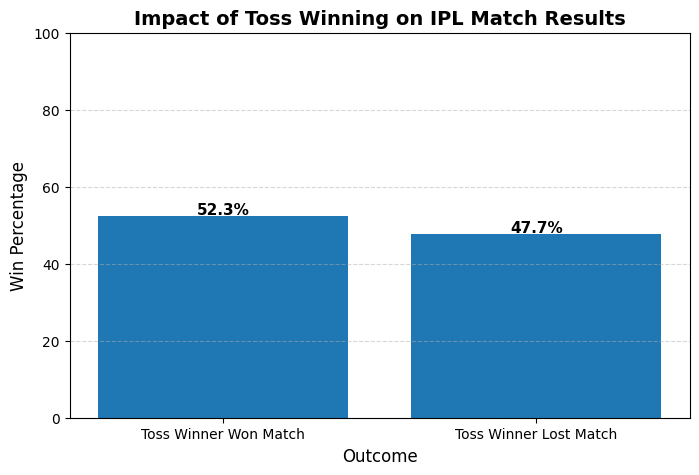

In [28]:
import matplotlib.pyplot as plt

labels = ['Toss Winner Won Match', 'Toss Winner Lost Match']
values = [52.3, 47.7]

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values)

plt.ylabel("Win Percentage", fontsize=12)
plt.xlabel("Outcome", fontsize=12)

plt.title(
    "Impact of Toss Winning on IPL Match Results",
    fontsize=14,
    fontweight='bold'
)

for bar in bars:
    
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0,100)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Phase Wise Analysis

In [29]:
def get_phase(over):

    if over <= 6:
        return 'Powerplay'

    elif over <= 15:
        return 'Middle Overs'

    else:
        return 'Death Overs'


df['phase'] = df['over'].apply(get_phase)

In [30]:
df['is_winner'] = df['batting_team'] == df['winner']

In [31]:
phase_runs = df.groupby(
    ['match_id', 'batting_team', 'phase', 'is_winner']
)['total_runs'].sum().reset_index()

In [32]:
phase_runs.head()

,match_id,batting_team,phase,is_winner,total_runs
0,1082591,Royal Challengers Bengaluru,Death Overs,False,21
1,1082591,Royal Challengers Bengaluru,Middle Overs,False,90
2,1082591,Royal Challengers Bengaluru,Powerplay,False,61
3,1082591,Sunrisers Hyderabad,Death Overs,True,52
4,1082591,Sunrisers Hyderabad,Middle Overs,True,91


In [33]:
avg_phase_runs = phase_runs.groupby(
    ['phase', 'is_winner']
)['total_runs'].mean().reset_index()

In [34]:
print(avg_phase_runs)

          phase  is_winner  total_runs
0   Death Overs      False   35.599163
1   Death Overs       True   38.882080
2  Middle Overs      False   68.133172
3  Middle Overs       True   75.985762
4     Powerplay      False   52.159036
5     Powerplay       True   58.711074


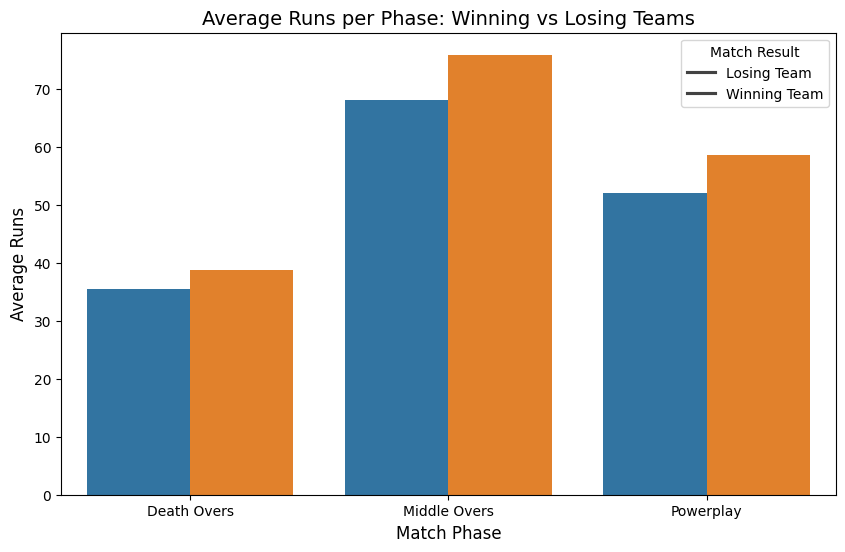

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=avg_phase_runs,
    x='phase',
    y='total_runs',
    hue='is_winner'
)

plt.title(
    "Average Runs per Phase: Winning vs Losing Teams",
    fontsize=14
)

plt.xlabel("Match Phase", fontsize=12)

plt.ylabel("Average Runs", fontsize=12)

plt.legend(
    title='Match Result',
    labels=['Losing Team', 'Winning Team']
)

plt.show()

In [36]:
plt.savefig("phase_wise_analysis.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

# Phase-wise Run Analysis

This analysis compares the average runs scored by winning and losing teams across different phases of the innings.

Winning teams consistently scored more runs in every phase. The largest performance gap appeared during the middle overs, suggesting that maintaining momentum between the powerplay and death overs plays a crucial role in IPL victories.

## Surprising Insight

Contrary to common belief that death overs decide T20 matches, the analysis revealed that the middle overs showed the largest run difference between winning and losing teams. This suggests that controlling the middle phase may be more important than explosive finishing alone.

In [37]:
# Next Step

# Top Bowlers and Batters

In [38]:
top_batters = (
    df.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top_batters)

batter
V Kohli      9155
RG Sharma    7291
S Dhawan     6769
DA Warner    6567
KL Rahul     5712
Name: batsman_runs, dtype: int64


In [39]:
top_batters_df = top_batters.reset_index()

top_batters_df.columns = ['Batter', 'Runs']

top_batters_df

,Batter,Runs
0,V Kohli,9155
1,RG Sharma,7291
2,S Dhawan,6769
3,DA Warner,6567
4,KL Rahul,5712


In [40]:
top_bowlers = (
    df[df['is_wicket'] == 1]
    .groupby('bowler')['is_wicket']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top_bowlers)

bowler
YS Chahal    238
B Kumar      237
SP Narine    225
DJ Bravo     207
JJ Bumrah    207
Name: is_wicket, dtype: int64


In [41]:
top_bowlers_df = top_bowlers.reset_index()

top_bowlers_df.columns = ['Bowler', 'Wickets']

top_bowlers_df

,Bowler,Wickets
0,YS Chahal,238
1,B Kumar,237
2,SP Narine,225
3,DJ Bravo,207
4,JJ Bumrah,207


In [42]:
final_table = pd.concat(
    [top_batters_df, top_bowlers_df],
    axis=1
)

final_table

,Batter,Runs,Bowler,Wickets
0,V Kohli,9155,YS Chahal,238
1,RG Sharma,7291,B Kumar,237
2,S Dhawan,6769,SP Narine,225
3,DA Warner,6567,DJ Bravo,207
4,KL Rahul,5712,JJ Bumrah,207


In [43]:
final_table.style\
.set_caption("Top 5 IPL Batters and Bowlers")\
.hide(axis='index')

Batter,Runs,Bowler,Wickets
V Kohli,9155,YS Chahal,238
RG Sharma,7291,B Kumar,237
S Dhawan,6769,SP Narine,225
DA Warner,6567,DJ Bravo,207
KL Rahul,5712,JJ Bumrah,207


In [44]:
innings_teams = df.groupby(
    ['match_id', 'inning']
)['batting_team'].first().reset_index()

innings_teams.head()

,match_id,inning,batting_team
0,1082591,1,Sunrisers Hyderabad
1,1082591,2,Royal Challengers Bengaluru
2,1082592,1,Mumbai Indians
3,1082592,2,Rising Pune Supergiants
4,1082593,1,Gujarat Lions


In [45]:
first_innings = innings_teams[
    innings_teams['inning'] == 1
][['match_id', 'batting_team']]

first_innings.columns = ['match_id', 'team1']

second_innings = innings_teams[
    innings_teams['inning'] == 2
][['match_id', 'batting_team']]

second_innings.columns = ['match_id', 'team2']

In [46]:
match_teams = first_innings.merge(
    second_innings,
    on='match_id'
)

match_teams.head()

,match_id,team1,team2
0,1082591,Sunrisers Hyderabad,Royal Challengers Bengaluru
1,1082592,Mumbai Indians,Rising Pune Supergiants
2,1082593,Gujarat Lions,Kolkata Knight Riders
3,1082594,Rising Pune Supergiants,Punjab Kings
4,1082595,Royal Challengers Bengaluru,Delhi Capitals


In [47]:
match_winner = matches[['match_id', 'winner']]

match_teams = match_teams.merge(
    match_winner,
    on='match_id'
)

In [48]:
match_teams['batting_second_won'] = (
    match_teams['team2'] == match_teams['winner']
)

In [49]:
chasing_win_percentage = (
    match_teams['batting_second_won']
    .mean()
) * 100

print(f"Batting Second Win %: {chasing_win_percentage:.2f}%")

Batting Second Win %: 53.85%


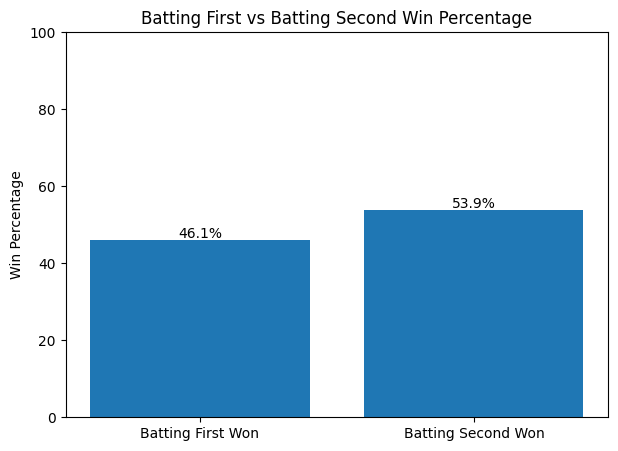

In [50]:
labels = ['Batting First Won', 'Batting Second Won']

values = [
    100 - chasing_win_percentage,
    chasing_win_percentage
]

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

bars = plt.bar(labels, values)

plt.ylabel("Win Percentage")

plt.title("Batting First vs Batting Second Win Percentage")

for bar in bars:
    
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center'
    )

plt.ylim(0,100)

plt.show()

In [51]:
match_info = df[[
    'match_id',
    'toss_winner',
    'winner',
    'toss_decision'
]].drop_duplicates()

match_info.head()

,match_id,toss_winner,winner,toss_decision
0,598025,Punjab Kings,Punjab Kings,field
244,1473452,Sunrisers Hyderabad,Kolkata Knight Riders,field
472,598004,Royal Challengers Bengaluru,No Result,bat
733,1370352,Mumbai Indians,Gujarat Titans,field
975,1216499,Mumbai Indians,Mumbai Indians,field


In [52]:
toss_winner_matches = match_info[
    match_info['toss_winner'] == match_info['toss_winner']
]

In [53]:
bat_first = toss_winner_matches[
    toss_winner_matches['toss_decision'] == 'bat'
]

field_first = toss_winner_matches[
    toss_winner_matches['toss_decision'] == 'field'
]

In [54]:
bat_first_win_pct = (
    (bat_first['toss_winner'] == bat_first['winner'])
    .mean()
) * 100

In [55]:
field_first_win_pct = (
    (field_first['toss_winner'] == field_first['winner'])
    .mean()
) * 100

In [56]:
print(f"Bat First Win %: {bat_first_win_pct:.2f}%")

print(f"Field First Win %: {field_first_win_pct:.2f}%")

Bat First Win %: 44.34%
Field First Win %: 53.76%


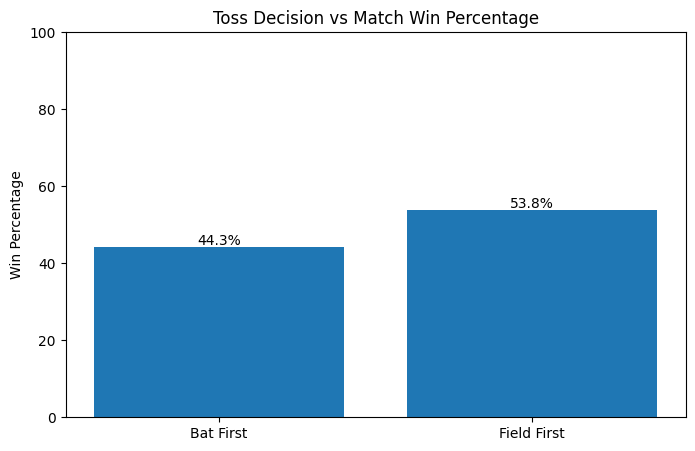

In [57]:
import matplotlib.pyplot as plt

labels = ['Bat First', 'Field First']

values = [
    bat_first_win_pct,
    field_first_win_pct
]

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values)

plt.ylabel("Win Percentage")

plt.title(
    "Toss Decision vs Match Win Percentage"
)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center'
    )

plt.ylim(0,100)

plt.show()

In [58]:
innings_scores = df.groupby(
    ['match_id', 'inning']
)['total_runs'].sum().reset_index()

In [59]:
first_innings = innings_scores[
    innings_scores['inning'] == 1
][['match_id', 'total_runs']]

first_innings.columns = [
    'match_id',
    'first_score'
]

second_innings = innings_scores[
    innings_scores['inning'] == 2
][['match_id', 'total_runs']]

second_innings.columns = [
    'match_id',
    'second_score'
]

In [60]:
match_scores = first_innings.merge(
    second_innings,
    on='match_id'
)

In [61]:
match_winners = df[[
    'match_id',
    'winner'
]].drop_duplicates()

match_scores = match_scores.merge(
    match_winners,
    on='match_id'
)

In [62]:
innings_teams = df.groupby(
    ['match_id', 'inning']
)['batting_team'].first().reset_index()

In [63]:
team1 = innings_teams[
    innings_teams['inning'] == 1
][['match_id', 'batting_team']]

team1.columns = [
    'match_id',
    'team1'
]

team2 = innings_teams[
    innings_teams['inning'] == 2
][['match_id', 'batting_team']]

team2.columns = [
    'match_id',
    'team2'
]

In [64]:
match_scores = match_scores.merge(
    team1,
    on='match_id'
)

match_scores = match_scores.merge(
    team2,
    on='match_id'
)

In [67]:
last_over = df[
    df['inning'] == 2
].groupby('match_id')['over'].max().reset_index()

last_over.columns = [
    'match_id',
    'last_over'
]

In [68]:
match_scores = match_scores.merge(
    last_over,
    on='match_id'
)

In [69]:
close_matches = match_scores[

    # Batting first wins by <=10 runs
    (
        (match_scores['winner'] == match_scores['team1']) &

        (
            (
                match_scores['first_score']
                -
                match_scores['second_score']
            ) <= 10
        )
    )

    |

    # Batting second wins in final over
    (
        (match_scores['winner'] == match_scores['team2']) &

        (
            match_scores['last_over'] >= 19
        )
    )
]

In [70]:
close_match_percentage = (
    len(close_matches)
    /
    len(match_scores)
) * 100

print(
    f"Close Match Percentage: "
    f"{close_match_percentage:.2f}%"
)


Close Match Percentage: 30.74%


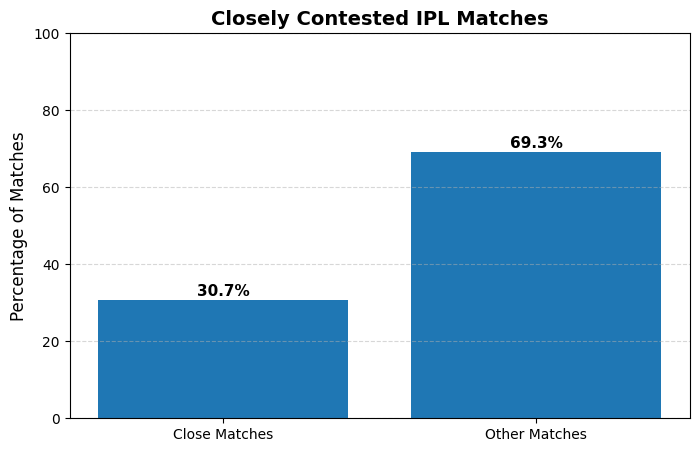

In [71]:
import matplotlib.pyplot as plt

# Labels
labels = [
    'Close Matches',
    'Other Matches'
]

# Values
values = [
    close_match_percentage,
    100 - close_match_percentage
]

# Create figure
plt.figure(figsize=(8,5))

# Create bars
bars = plt.bar(labels, values)

# Title
plt.title(
    "Closely Contested IPL Matches",
    fontsize=14,
    fontweight='bold'
)

# Axis label
plt.ylabel(
    "Percentage of Matches",
    fontsize=12
)

# Add percentage labels
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

# Y-axis limit
plt.ylim(0,100)

# Show chart
plt.show()

In [72]:
plt.savefig(
    "close_match_analysis.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>